# Imports

In [1]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load data

In [ ]:
# Load shared dataset
data = np.load('../data/fashion_data_complete.npz', allow_pickle=True)

# Standardized data
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# Non-standardized but normalized data (saved from preprocessing)
X_train_norm_full = data['X_train_raw']
X_test_norm = data['X_test_raw']

class_names = data['class_names']

print("Standardized train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Normalized full-train shape:", X_train_norm_full.shape)
print("Normalized test shape:", X_test_norm.shape)
print("Classes:", class_names)

Standardized train shape: (50000, 784)
Validation shape: (10000, 784)
Test shape: (10000, 784)
Normalized full-train shape: (50000, 784)
Normalized test shape: (10000, 784)
Classes: ['T-shirt/top' 'Trouser' 'Pullover' 'Dress' 'Coat' 'Sandal' 'Shirt'
 'Sneaker' 'Bag' 'Ankle boot']


# Rebuild normalized train/val split for ablation

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

RANDOM_SEED = 42

# Đọc lại file CSV gốc để lấy nhãn (labels) chuẩn xác
train_df = pd.read_csv('../data/fashion-mnist_train.csv')
y_train_orig = train_df['label'].values

# Lấy dữ liệu thô (chưa standardization) và chia cho 255 để normalize về [0,1]
X_train_norm_full = train_df.drop('label', axis=1).values.astype('float32') / 255.0

# Chia tập train/val với test_size=10000 và sử dụng stratify
X_train_norm, X_val_norm, y_train_norm, y_val_norm = train_test_split(
    X_train_norm_full,
    y_train_orig,
    test_size=10000,
    random_state=RANDOM_SEED,
    stratify=y_train_orig
)

print("Normalized ablation split:")
print("X_train_norm:", X_train_norm.shape)
print("X_val_norm:", X_val_norm.shape)

Normalized ablation split:
X_train_norm: (50000, 784)
X_val_norm: (10000, 784)


## Ablation Variants

To identify which components matter most, we test the following variants:

1. **Baseline**: best MLP configuration.
2. **No Standardization**: use only normalized pixel values instead of standardized features.
3. **Smaller Network**: reduce the hidden-layer structure from (256, 128) to (256,).
4. **No Early Stopping**: disable early stopping during training.
5. **Lower Learning Rate**: reduce the initial learning rate from 0.001 to 0.0005.

Each variant changes only one factor while keeping the others fixed.

# Define baseline and ablation settings

In [ ]:
baseline_config = {
    "hidden_layer_sizes": (256, 128),
    "activation": "relu",
    "solver": "adam",
    "alpha": 1e-5,
    "batch_size": 128,
    "learning_rate_init": 0.001,
    "max_iter": 30,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 5,
    "random_state": 42
}

ablation_configs = [
    {
        "name": "Baseline",
        "description": "Best MLP configuration",
        "use_standardized": True,
        "params": baseline_config.copy()
    },
    {
        "name": "No Standardization",
        "description": "Use normalized [0,1] pixels only",
        "use_standardized": False,
        "params": baseline_config.copy()
    },
    {
        "name": "Smaller Network",
        "description": "Reduce hidden layers from (256,128) to (256,)",
        "use_standardized": True,
        "params": {
            **baseline_config,
            "hidden_layer_sizes": (256,)
        }
    },
    {
        "name": "No Early Stopping",
        "description": "Disable early stopping",
        "use_standardized": True,
        "params": {
            **baseline_config,
            "early_stopping": False
        }
    },
    {
        "name": "Lower Learning Rate",
        "description": "Reduce learning rate from 0.001 to 0.0005",
        "use_standardized": True,
        "params": {
            **baseline_config,
            "learning_rate_init": 0.0005
        }
    }
]

## Train and Evaluate Each Variant

Each ablation setting is trained and evaluated using the same protocol.

For each model, we record:
- test accuracy,
- macro F1-score,
- training time,
- inference time,
- latency per sample.

# Training + evaluation helper

In [5]:
def train_and_evaluate_mlp(config_name, description, params, use_standardized=True):
    if use_standardized:
        Xtr, ytr = X_train, y_train
        Xva, yva = X_val, y_val
        Xte, yte = X_test, y_test
        data_type = "standardized"
    else:
        Xtr, ytr = X_train_norm, y_train_norm
        Xva, yva = X_val_norm, y_val_norm
        Xte, yte = X_test_norm, y_test
        data_type = "normalized_only"

    print(f"\n{'='*60}")
    print(f"Running: {config_name}")
    print(f"Description: {description}")
    print(f"Data type: {data_type}")
    print(f"Params: {params}")

    model = MLPClassifier(**params)

    start_train = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - start_train

    start_infer = time.time()
    y_pred = model.predict(Xte)
    infer_time = time.time() - start_infer

    accuracy = accuracy_score(yte, y_pred)
    macro_f1 = f1_score(yte, y_pred, average='macro')

    report = classification_report(
        yte, y_pred,
        target_names=class_names,
        output_dict=True
    )

    result = {
        "name": config_name,
        "description": description,
        "data_type": data_type,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time_sec": train_time,
        "inference_time_sec": infer_time,
        "latency_ms_per_sample": (infer_time / len(yte)) * 1000,
        "params": params,
        "report": report,
        "model": model
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Train time: {train_time:.2f}s")
    print(f"Inference time: {infer_time:.4f}s")
    print(f"Latency per sample: {result['latency_ms_per_sample']:.6f} ms")

    return result

# Run ablation experiments

In [6]:
ablation_results = []

for cfg in ablation_configs:
    result = train_and_evaluate_mlp(
        config_name=cfg["name"],
        description=cfg["description"],
        params=cfg["params"],
        use_standardized=cfg["use_standardized"]
    )
    ablation_results.append(result)


Running: Baseline
Description: Best MLP configuration
Data type: standardized
Params: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-05, 'batch_size': 128, 'learning_rate_init': 0.001, 'max_iter': 30, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 5, 'random_state': 42}
Accuracy: 0.8924
Macro F1: 0.8922
Train time: 112.19s
Inference time: 0.2120s
Latency per sample: 0.021200 ms

Running: No Standardization
Description: Use normalized [0,1] pixels only
Data type: normalized_only
Params: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-05, 'batch_size': 128, 'learning_rate_init': 0.001, 'max_iter': 30, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 5, 'random_state': 42}
Accuracy: 0.8921
Macro F1: 0.8917
Train time: 117.05s
Inference time: 0.1789s
Latency per sample: 0.017893 ms

Running: Smaller Network
Description: Reduce hidden layers from (256,128) to (256,

d:\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8959
Macro F1: 0.8963
Train time: 171.40s
Inference time: 0.0617s
Latency per sample: 0.006174 ms

Running: Lower Learning Rate
Description: Reduce learning rate from 0.001 to 0.0005
Data type: standardized
Params: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-05, 'batch_size': 128, 'learning_rate_init': 0.0005, 'max_iter': 30, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 5, 'random_state': 42}
Accuracy: 0.8944
Macro F1: 0.8942
Train time: 62.92s
Inference time: 0.0701s
Latency per sample: 0.007010 ms


# Build summary table

In [7]:
summary_rows = []

baseline_acc = None
baseline_f1 = None

for r in ablation_results:
    if r["name"] == "Baseline":
        baseline_acc = r["accuracy"]
        baseline_f1 = r["macro_f1"]
        break

for r in ablation_results:
    summary_rows.append({
        "Configuration": r["name"],
        "Data Type": r["data_type"],
        "Accuracy": round(r["accuracy"], 4),
        "Macro F1": round(r["macro_f1"], 4),
        "Delta Accuracy": round(r["accuracy"] - baseline_acc, 4),
        "Delta Macro F1": round(r["macro_f1"] - baseline_f1, 4),
        "Train Time (s)": round(r["train_time_sec"], 2),
        "Inference Time (s)": round(r["inference_time_sec"], 4),
        "Latency (ms/sample)": round(r["latency_ms_per_sample"], 6)
    })

ablation_df = pd.DataFrame(summary_rows)
ablation_df = ablation_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print(ablation_df)

         Configuration        Data Type  Accuracy  Macro F1  Delta Accuracy  \
0    No Early Stopping     standardized    0.8959    0.8963          0.0035   
1  Lower Learning Rate     standardized    0.8944    0.8942          0.0020   
2      Smaller Network     standardized    0.8935    0.8929          0.0011   
3             Baseline     standardized    0.8924    0.8922          0.0000   
4   No Standardization  normalized_only    0.8921    0.8917         -0.0003   

   Delta Macro F1  Train Time (s)  Inference Time (s)  Latency (ms/sample)  
0          0.0040          171.40              0.0617             0.006174  
1          0.0020           62.92              0.0701             0.007010  
2          0.0006           96.81              0.3671             0.036713  
3          0.0000          112.19              0.2120             0.021200  
4         -0.0005          117.05              0.1789             0.017893  


# Save results

In [8]:
os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

ablation_df.to_csv("../results/mlp_ablation_results.csv", index=False)
print("Saved: ../results/mlp_ablation_results.csv")

# Save each trained model if needed
for r in ablation_results:
    safe_name = r["name"].lower().replace(" ", "_")
    joblib.dump(r["model"], f"../models/mlp_ablation_{safe_name}.joblib")

print("Saved ablation models to ../models/")

Saved: ../results/mlp_ablation_results.csv
Saved ablation models to ../models/


# Plot accuracy comparison

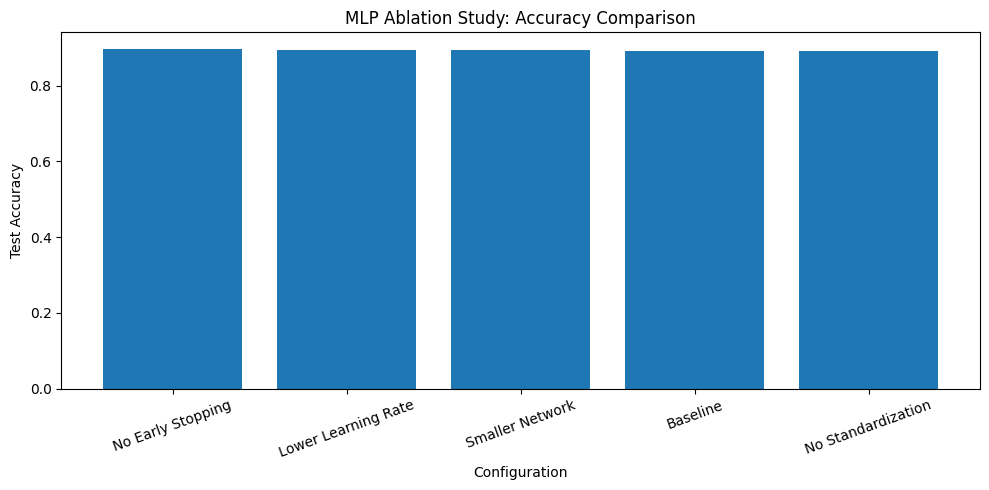

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["Configuration"], ablation_df["Accuracy"])
plt.title("MLP Ablation Study: Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xlabel("Configuration")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot Macro F1 comparison

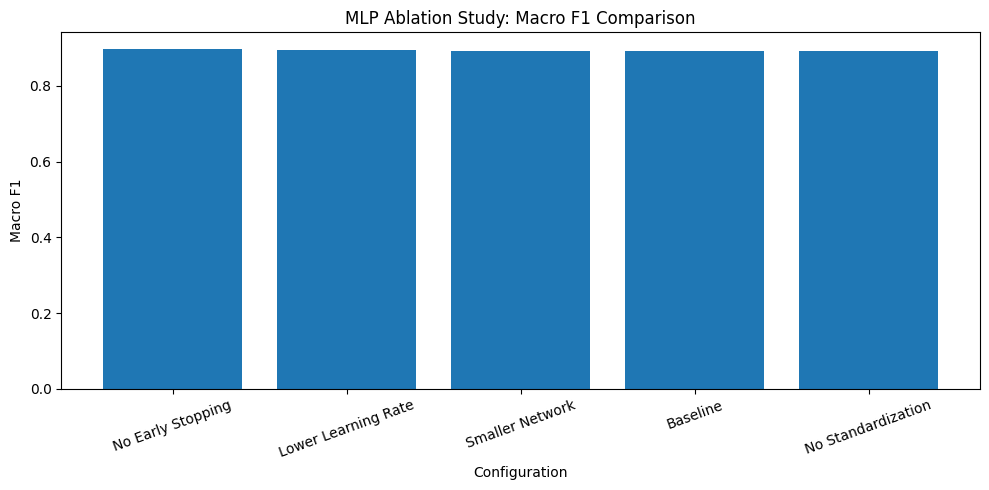

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["Configuration"], ablation_df["Macro F1"])
plt.title("MLP Ablation Study: Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.xlabel("Configuration")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot delta accuracy from baseline

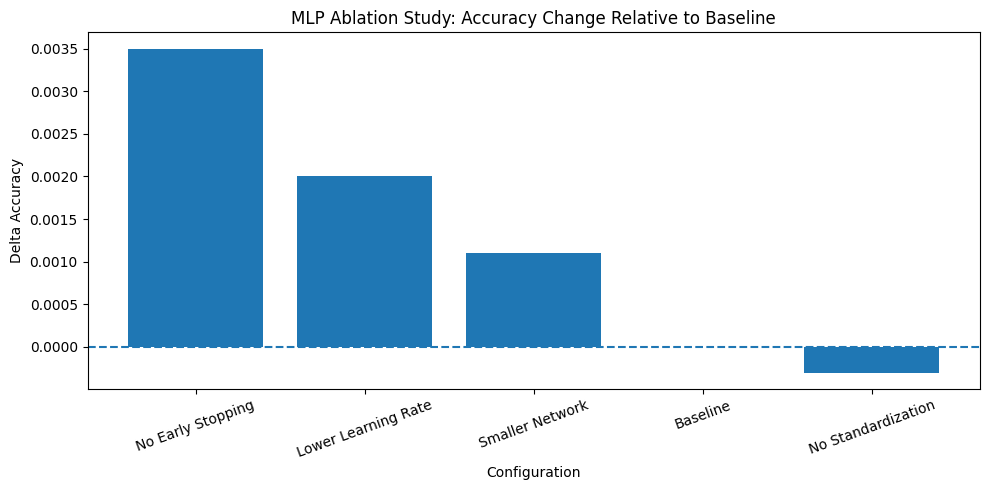

In [10]:
delta_df = ablation_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(delta_df["Configuration"], delta_df["Delta Accuracy"])
plt.axhline(0, linestyle='--')
plt.title("MLP Ablation Study: Accuracy Change Relative to Baseline")
plt.ylabel("Delta Accuracy")
plt.xlabel("Configuration")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Find hardest classes for each configuration

In [11]:
for r in ablation_results:
    print(f"\n{'='*70}")
    print(f"{r['name']} - Per-class F1")
    per_class = []
    for cls in class_names:
        per_class.append((cls, r["report"][cls]["f1-score"]))
    per_class = sorted(per_class, key=lambda x: x[1])
    for cls, f1 in per_class:
        print(f"{cls:15s}: {f1:.4f}")


Baseline - Per-class F1
Shirt          : 0.7321
Pullover       : 0.8214
Coat           : 0.8275
T-shirt/top    : 0.8337
Dress          : 0.9061
Sneaker        : 0.9414
Ankle boot     : 0.9500
Sandal         : 0.9602
Bag            : 0.9695
Trouser        : 0.9806

No Standardization - Per-class F1
Shirt          : 0.7185
Pullover       : 0.8135
T-shirt/top    : 0.8337
Coat           : 0.8412
Dress          : 0.9081
Sneaker        : 0.9371
Ankle boot     : 0.9480
Sandal         : 0.9602
Bag            : 0.9760
Trouser        : 0.9811

Smaller Network - Per-class F1
Shirt          : 0.7186
Pullover       : 0.8243
Coat           : 0.8405
T-shirt/top    : 0.8406
Dress          : 0.9013
Sneaker        : 0.9438
Sandal         : 0.9526
Ankle boot     : 0.9583
Bag            : 0.9677
Trouser        : 0.9810

No Early Stopping - Per-class F1
Shirt          : 0.7410
Pullover       : 0.8191
T-shirt/top    : 0.8384
Coat           : 0.8491
Dress          : 0.9135
Sneaker        : 0.9432
Ankle boot